In [2]:
import pandas as pd

# Load dataset with encoding
df = pd.read_csv(
    "../data/sales.csv/sales.csv",
    encoding="latin1"
)

# Preview
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print(df.shape)

print(df.columns)

df.info()

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Co

In [4]:
# Convert date column

df["Order Date"] = pd.to_datetime(df["Order Date"])

# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

print("\nShape after cleaning:")
print(df.shape)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Shape after cleaning:
(9994, 21)


In [5]:
# Group sales by date

sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [6]:
sales["Day_Number"] = (
    sales["Order Date"]
    - sales["Order Date"].min()
).dt.days

sales.head()

,Order Date,Sales,Day_Number
0,2014-01-03,16.448,0
1,2014-01-04,288.060,1
2,2014-01-05,19.536,2
3,2014-01-06,4407.100,3
4,2014-01-07,87.158,4


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = sales[["Day_Number"]]
y = sales["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [8]:
# Convert date column

df["Order Date"] = pd.to_datetime(df["Order Date"])

# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

print("\nShape after cleaning:")
print(df.shape)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Shape after cleaning:
(9994, 21)


In [9]:
# Group sales by date

sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [10]:
sales["Day_Number"] = (
    sales["Order Date"]
    - sales["Order Date"].min()
).dt.days

sales.head()

,Order Date,Sales,Day_Number
0,2014-01-03,16.448,0
1,2014-01-04,288.060,1
2,2014-01-05,19.536,2
3,2014-01-06,4407.100,3
4,2014-01-07,87.158,4


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = sales[["Day_Number"]]

y = sales["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [12]:
# Predict on test data

pred = model.predict(X_test)

print(pred[:10])

[2161.60151759 2163.13839287 2163.90683051 2164.67526815 2165.44370579
 2166.21214343 2166.98058107 2167.74901871 2168.51745635 2169.28589399]


In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(
    y_test,
    pred
)

mse = mean_squared_error(
    y_test,
    pred
)

print("MAE:", mae)
print("MSE:", mse)

MAE: 1794.174992880425
MSE: 6033005.060912234


In [14]:
future_days = 30

future = pd.DataFrame({
    "Day_Number":
    range(
        sales["Day_Number"].max()+1,
        sales["Day_Number"].max()+future_days+1
    )
})

future_pred = model.predict(future)

print(future_pred)

[2369.84811803 2370.61655567 2371.38499331 2372.15343095 2372.92186859
 2373.69030623 2374.45874387 2375.22718151 2375.99561915 2376.76405679
 2377.53249443 2378.30093207 2379.06936971 2379.83780735 2380.60624499
 2381.37468262 2382.14312026 2382.9115579  2383.67999554 2384.44843318
 2385.21687082 2385.98530846 2386.7537461  2387.52218374 2388.29062138
 2389.05905902 2389.82749666 2390.5959343  2391.36437194 2392.13280958]


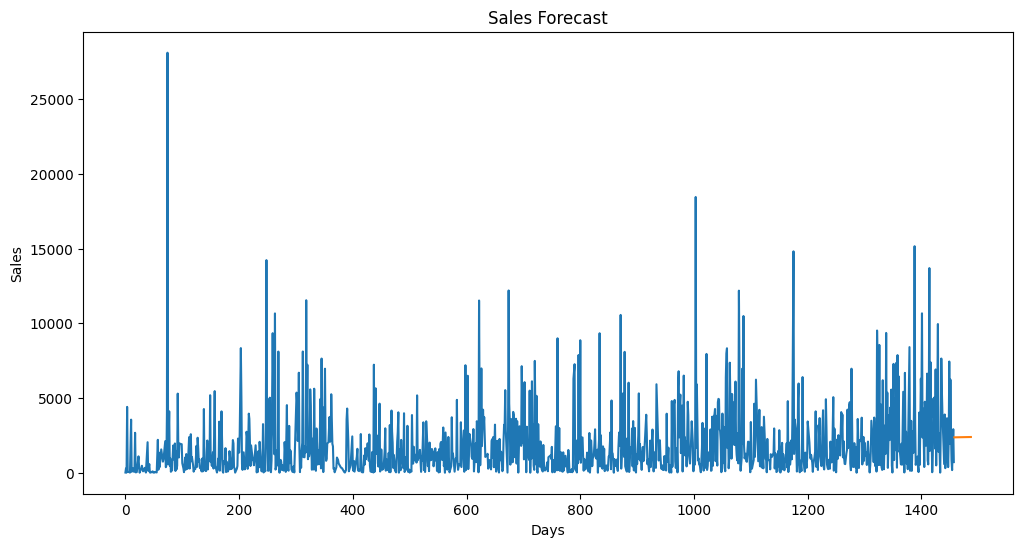

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    sales["Day_Number"],
    sales["Sales"]
)

plt.plot(
    future["Day_Number"],
    future_pred
)

plt.title(
    "Sales Forecast"
)

plt.xlabel(
    "Days"
)

plt.ylabel(
    "Sales"
)

plt.savefig(
    "../outputs/forecast_plot.png"
)

plt.show()